# Tracing the Euro — Visualizing Exchange Rate Trends Before, During and After the COVID-19 Pandemic

## Aim

* To create explanatory data visualizations to illustrate exchange rate trends for the Euro (€)

* Focus on comparison with the US Dollar (USD, $) and the UK Pound Sterling (GBP, £) before, during and after the COVID-19 Pandemic

Gestalt principles and pre-attentive attributes will be considered when designing and creating the graphics.

## Dataset Background

The dataset used for this work was put together by Daria Chemkaeva and is publically available on [Kaggle](https://www.kaggle.com/datasets/lsind18/euro-exchange-daily-rates-19992020). 

The dataset is updated roughly every quarter and covers dates starting from January 4th 1999. At the time of writing, a copy of the dataset was acquired on September 8th 2025 and contains data up to April 2nd 2025.

## Importing Modules and Reading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style

%matplotlib inline
pd.options.display.max_columns = 41 # increase maximum number of columns rendered in each output to avoid truncated outputs

In [2]:
exchange_rates = pd.read_csv('euro-daily-hist_1999_2025.csv')
exchange_rates.head()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],[Estonian kroon ],[UK pound sterling ],[Greek drachma ],[Hong Kong dollar ],[Croatian kuna ],[Hungarian forint ],[Indonesian rupiah ],[Israeli shekel ],[Indian rupee ],[Iceland krona ],[Japanese yen ],[Korean won ],[Lithuanian litas ],[Latvian lats ],[Maltese lira ],[Mexican peso ],[Malaysian ringgit ],[Norwegian krone ],[New Zealand dollar ],[Philippine peso ],[Polish zloty ],[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2025-04-02,1.7146,1.9558,6.1212,1.5479,0.9543,7.8529,NaN,24.963,7.4611,NaN,0.83455,NaN,8.4067,NaN,400.95,18058.29,3.9977,92.362,143.7,161.22,1579.27,NaN,NaN,NaN,21.9953,4.8117,11.2745,1.8821,61.806,4.1775,4.9775,NaN,10.764,1.4508,NaN,NaN,36.93,40.9573,1.0803,20.1042
1,2025-04-01,1.7255,1.9558,6.1679,1.5529,0.952,7.8431,NaN,24.954,7.4616,NaN,0.83665,NaN,8.3943,NaN,402.63,18062.4,3.9973,92.384,143.7,160.93,1588.43,NaN,NaN,NaN,22.138,4.7872,11.318,1.9001,61.794,4.1863,4.9774,NaN,10.816,1.4492,NaN,NaN,36.846,40.9201,1.0788,19.7741
2,2025-03-31,1.7318,1.9558,6.2507,1.5533,0.9531,7.8442,NaN,24.962,7.4613,NaN,0.83536,NaN,8.413,NaN,402.35,17992.97,4.0256,92.3955,142.7,161.6,1594.71,NaN,NaN,NaN,22.0627,4.7992,11.413,1.9035,61.919,4.184,4.9771,NaN,10.849,1.4519,NaN,NaN,36.706,41.0399,1.0815,19.8782
3,2025-03-28,1.712,1.9558,6.2252,1.5444,0.9525,7.8445,NaN,24.96,7.4616,NaN,0.83358,NaN,8.3988,NaN,403.13,17909.52,3.984,92.346,142.5,162.64,1585.65,NaN,NaN,NaN,21.9676,4.7912,11.294,1.8845,61.947,4.1775,4.9774,NaN,10.82,1.4481,NaN,NaN,36.664,41.0387,1.0797,19.6113
4,2025-03-27,1.7101,1.9558,6.2154,1.5425,0.9524,7.8361,NaN,24.982,7.4605,NaN,0.83318,NaN,8.3867,NaN,400.98,17887.25,3.9595,92.462,142.3,162.55,1580.16,NaN,NaN,NaN,21.8876,4.7794,11.3435,1.8778,61.911,4.1968,4.9773,NaN,10.8235,1.445,NaN,NaN,36.529,40.9940,1.0785,19.7061


In [3]:
exchange_rates.tail()

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],[Estonian kroon ],[UK pound sterling ],[Greek drachma ],[Hong Kong dollar ],[Croatian kuna ],[Hungarian forint ],[Indonesian rupiah ],[Israeli shekel ],[Indian rupee ],[Iceland krona ],[Japanese yen ],[Korean won ],[Lithuanian litas ],[Latvian lats ],[Maltese lira ],[Mexican peso ],[Malaysian ringgit ],[Norwegian krone ],[New Zealand dollar ],[Philippine peso ],[Polish zloty ],[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
6780,1999-01-08,1.8406,NaN,NaN,1.7643,1.6138,NaN,0.58187,34.938,7.4433,15.6466,0.70940,324.00,9.0302,NaN,250.15,9321.63,NaN,NaN,80.99,130.09,1366.73,4.66430,0.6654,0.4419,11.4414,4.4295,8.5900,2.1557,44.295,4.0363,1.3143,27.2075,9.1650,1.9537,188.8400,42.560,42.5590,0.3718,1.1659,6.7855
6781,1999-01-07,1.8474,NaN,NaN,1.7602,1.6165,NaN,0.58187,34.886,7.4431,15.6466,0.70585,324.40,9.0131,NaN,250.09,9218.77,NaN,NaN,81.06,129.43,1337.16,4.65480,0.6627,0.4413,11.5511,4.4203,8.6295,2.1531,44.436,4.0165,1.3092,26.9876,9.1800,1.9436,188.8000,42.765,42.1678,0.3701,1.1632,6.8283
6782,1999-01-06,1.8820,NaN,NaN,1.7711,1.6116,NaN,0.58200,34.850,7.4452,15.6466,0.70760,324.72,9.1010,NaN,250.67,9337.68,NaN,NaN,81.54,131.42,1359.54,4.69940,0.6649,0.4420,11.4705,4.4637,8.7335,2.1890,44.872,4.0065,1.3168,27.4315,9.3050,1.9699,188.7000,42.778,42.6949,0.3722,1.1743,6.7307
6783,1999-01-05,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,34.917,7.4495,15.6466,0.71220,324.70,9.1341,NaN,250.80,9314.51,NaN,NaN,81.53,130.96,1373.01,4.71740,0.6657,0.4432,11.5960,4.4805,8.7745,2.2011,44.745,4.0245,1.3168,26.5876,9.4025,1.9655,188.7750,42.848,42.5048,0.3728,1.1790,6.7975
6784,1999-01-04,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,35.107,7.4501,15.6466,0.71110,327.15,9.1332,NaN,251.48,9433.61,NaN,NaN,81.48,133.73,1398.59,4.71700,0.6668,0.4432,11.6446,4.4798,8.8550,2.2229,45.510,4.0712,1.3111,25.2875,9.4696,1.9554,189.0450,42.991,42.6799,0.3723,1.1789,6.9358


In [4]:
exchange_rates.info()

<class 'pandas.DataFrame'>
RangeIndex: 6785 entries, 0 to 6784
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              6785 non-null   str    
 1   [Australian dollar ]      6785 non-null   str    
 2   [Bulgarian lev ]          6383 non-null   str    
 3   [Brazilian real ]         6517 non-null   str    
 4   [Canadian dollar ]        6785 non-null   str    
 5   [Swiss franc ]            6785 non-null   str    
 6   [Chinese yuan renminbi ]  6517 non-null   str    
 7   [Cypriot pound ]          2346 non-null   str    
 8   [Czech koruna ]           6785 non-null   str    
 9   [Danish krone ]           6785 non-null   str    
 10  [Estonian kroon ]         3130 non-null   str    
 11  [UK pound sterling ]      6785 non-null   str    
 12  [Greek drachma ]          520 non-null    str    
 13  [Hong Kong dollar ]       6785 non-null   str    
 14  [Croatian kuna ]   

The dataset spans 6,785 dates and includes data on 40 different currencies.

There are a number of fields with null values and some inconsistent datatypes - three fields are stored as 64-bit floats and thiry-eight are stored as object data types.

## Data Cleaning

We are interested in visualizing the exchange rate of the Euro relative to the US Dollar and UK GBP. We first reformat the field names of interest and convert the `Time` column to a datetime data type (before sorting by the `Time` column and resetting the index).

In [5]:
exchange_rates.rename(columns={"[US dollar ]": "US_dollar",
                               "[UK pound sterling ]": "UK_pound_sterling",
                               "Period\\Unit:": "Time"},
                      inplace=True)
exchange_rates['Time'] = pd.to_datetime(exchange_rates['Time'])
exchange_rates.sort_values('Time', inplace=True)
exchange_rates.reset_index(drop=True, inplace=True)

We isolate the data of interest, storing in the variables `usd` and `gbp`.

In [6]:
usd = exchange_rates[['Time', 'US_dollar']] 
usd

,Time,US_dollar
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659
...,...,...
6780,2025-03-27,1.0785
6781,2025-03-28,1.0797
6782,2025-03-31,1.0815
6783,2025-04-01,1.0788


In [7]:
usd["US_dollar"].value_counts()

US_dollar
-         62
1.2276     9
1.0867     8
1.0808     8
1.0888     8
          ..
1.037      1
1.0478     1
1.0447     1
1.0477     1
1.0411     1
Name: count, Length: 3837, dtype: int64

The US dollar column has 62 "-" entries, signifying missing values. These can be dropped. The field is also stored in the object data type, so must be converted to a float.

In [8]:
usd = usd[usd["US_dollar"] != "-"].copy() # drop rows with missing values
usd["US_dollar"] = usd["US_dollar"].astype(float) # cast data type to float
usd

,Time,US_dollar
0,1999-01-04,1.1789
1,1999-01-05,1.1790
2,1999-01-06,1.1743
3,1999-01-07,1.1632
4,1999-01-08,1.1659
...,...,...
6780,2025-03-27,1.0785
6781,2025-03-28,1.0797
6782,2025-03-31,1.0815
6783,2025-04-01,1.0788


In [9]:
usd.info()

<class 'pandas.DataFrame'>
Index: 6723 entries, 0 to 6784
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Time       6723 non-null   datetime64[us]
 1   US_dollar  6723 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 157.6 KB


The same steps are conducted on the GBP data.

In [10]:
gbp = exchange_rates[['Time', 'UK_pound_sterling']]
gbp

,Time,UK_pound_sterling
0,1999-01-04,0.71110
1,1999-01-05,0.71220
2,1999-01-06,0.70760
3,1999-01-07,0.70585
4,1999-01-08,0.70940
...,...,...
6780,2025-03-27,0.83318
6781,2025-03-28,0.83358
6782,2025-03-31,0.83536
6783,2025-04-01,0.83665


In [11]:
gbp["UK_pound_sterling"].value_counts()

UK_pound_sterling
-          62
0.84560     8
0.68880     7
0.63040     7
0.67930     7
           ..
0.8369      1
0.83663     1
0.83623     1
0.83318     1
0.83536     1
Name: count, Length: 4080, dtype: int64

In [12]:
gbp = gbp[gbp["UK_pound_sterling"] != "-"].copy() # drop rows with missing values
gbp["UK_pound_sterling"] = gbp["UK_pound_sterling"].astype(float) # cast data type to float
gbp

,Time,UK_pound_sterling
0,1999-01-04,0.71110
1,1999-01-05,0.71220
2,1999-01-06,0.70760
3,1999-01-07,0.70585
4,1999-01-08,0.70940
...,...,...
6780,2025-03-27,0.83318
6781,2025-03-28,0.83358
6782,2025-03-31,0.83536
6783,2025-04-01,0.83665


In [13]:
gbp.info()

<class 'pandas.DataFrame'>
Index: 6723 entries, 0 to 6784
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Time               6723 non-null   datetime64[us]
 1   UK_pound_sterling  6723 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 157.6 KB


---
## Visualizing the Euro-Dollar Exchange Rate

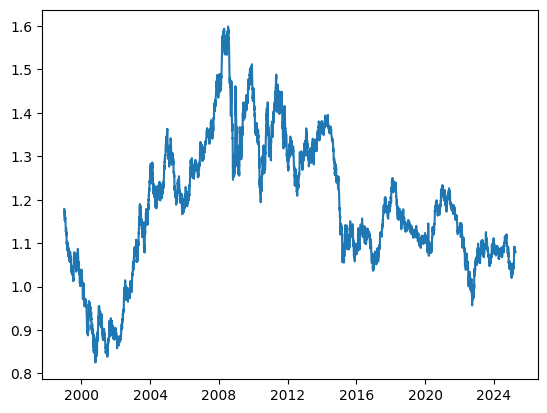

Exchange rate range: 0.78651 - 1.63769


In [14]:
plt.plot(usd["Time"], usd["US_dollar"])
bottom, top = plt.ylim()
plt.show()

print("Exchange rate range:", bottom, "-", top)

### Rolling-Average

The above plot is highly granular since daily variations are plotted. We want to roll-up to show the general, coarser trend. A **rolling-average** (aka moving-average) can be used to achieve this.

The rolling window is specified by the `Series.rolling()` method.

In [15]:
usd["monthly_rolling_mean"] = usd["US_dollar"].rolling(window=30).mean() # create a 30-day moving average column
usd

,Time,US_dollar,monthly_rolling_mean
0,1999-01-04,1.1789,NaN
1,1999-01-05,1.1790,NaN
2,1999-01-06,1.1743,NaN
3,1999-01-07,1.1632,NaN
4,1999-01-08,1.1659,NaN
...,...,...,...
6780,2025-03-27,1.0785,1.068030
6781,2025-03-28,1.0797,1.069093
6782,2025-03-31,1.0815,1.070233
6783,2025-04-01,1.0788,1.071370


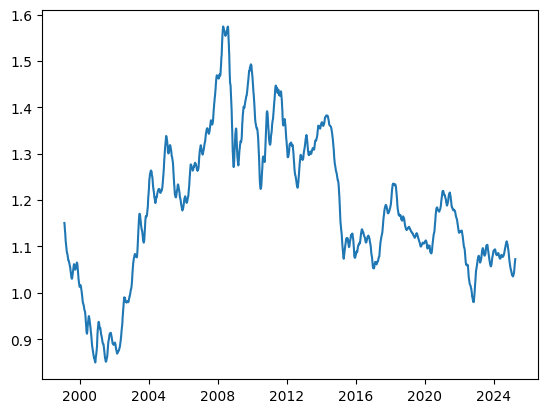

In [16]:
plt.plot(usd["Time"], usd["monthly_rolling_mean"])
plt.show()

The grid chart below shows the effect of modifying the rolling window on the granularity of the time series data.

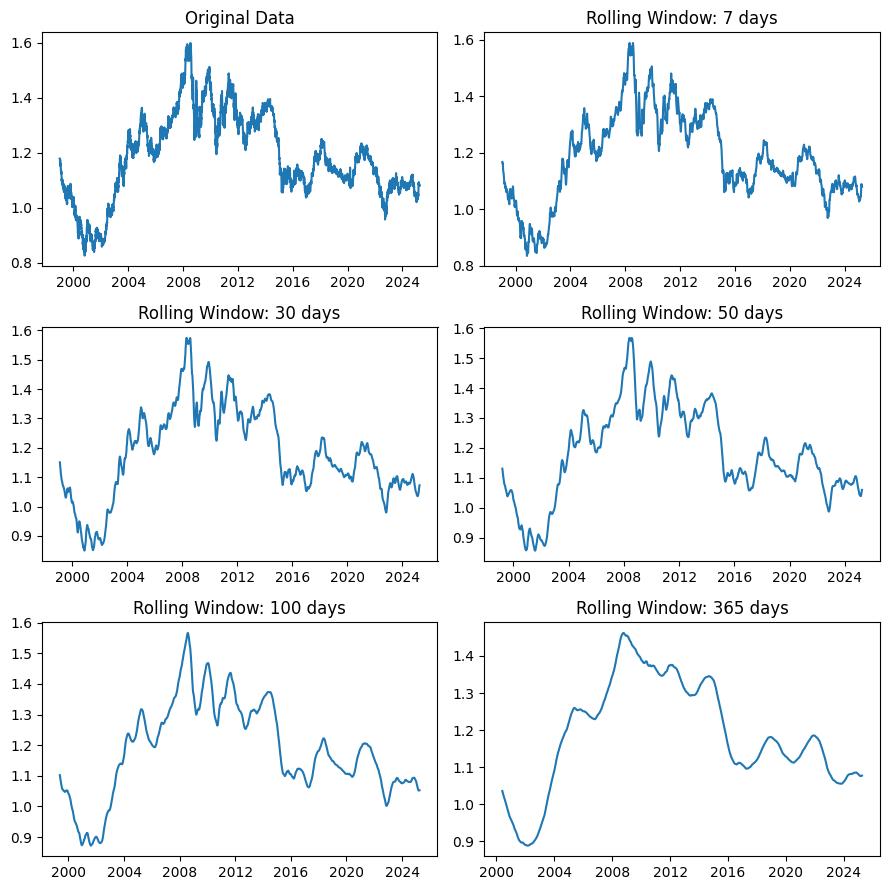

In [17]:
plt.figure(figsize=(9, 9))

plt.subplot(3,2,1)

plt.plot(usd["Time"], usd["US_dollar"])
plt.title("Original Data")

for i, window in zip(range(2,7), [7, 30, 50, 100, 365]):
  
    plt.subplot(3,2,i)

    plt.plot(usd["Time"], usd["US_dollar"].rolling(window=window).mean())
    plt.title("Rolling Window: " + str(window) + " days")
    
plt.tight_layout()
plt.show()

---
The same process is completed for the UK Pound Sterling:

## Visualizing the Euro-GBP Exchange Rate

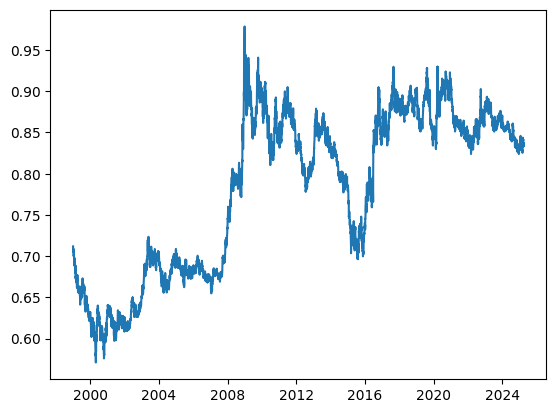

Exchange rate range: 0.5507275 - 0.9989225


In [18]:
plt.plot(gbp["Time"], gbp["UK_pound_sterling"])
bottom, top = plt.ylim()
plt.show()

print("Exchange rate range:", bottom, "-", top)

In [19]:
gbp["monthly_rolling_mean"] = gbp["UK_pound_sterling"].rolling(window=30).mean() # create a 30-day moving average column
gbp

,Time,UK_pound_sterling,monthly_rolling_mean
0,1999-01-04,0.71110,NaN
1,1999-01-05,0.71220,NaN
2,1999-01-06,0.70760,NaN
3,1999-01-07,0.70585,NaN
4,1999-01-08,0.70940,NaN
...,...,...,...
6780,2025-03-27,0.83318,0.834180
6781,2025-03-28,0.83358,0.834228
6782,2025-03-31,0.83536,0.834362
6783,2025-04-01,0.83665,0.834575


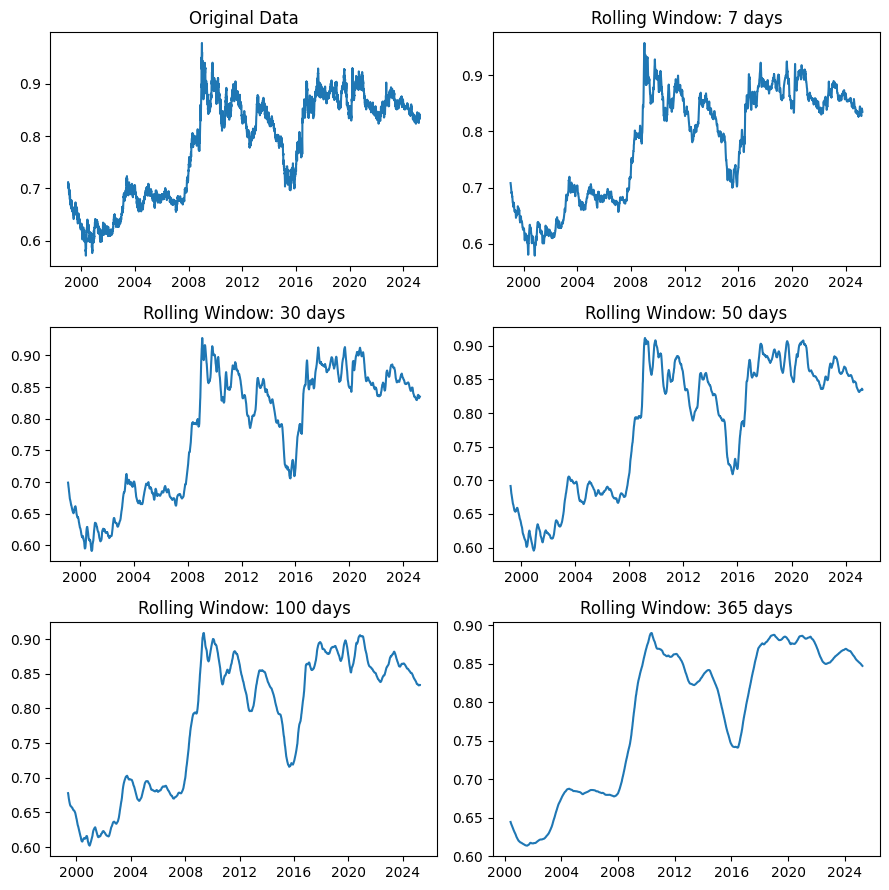

In [20]:
plt.figure(figsize=(9, 9))

plt.subplot(3,2,1)

plt.plot(gbp["Time"], gbp["UK_pound_sterling"])
plt.title("Original Data")

for i, window in zip(range(2,7), [7, 30, 50, 100, 365]):
  
    plt.subplot(3,2,i)

    plt.plot(gbp["Time"], gbp["UK_pound_sterling"].rolling(window=window).mean())
    plt.title("Rolling Window: " + str(window) + " days")
    
plt.tight_layout()
plt.show()

---
## How did the COVID-19 Pandemic Influence the Euro-to-Dollar Exchange Rate?

To assess the impact of the coronavirus pandemic, the dataset is filtered to contain dates between January 1st 2016 to the most recent date in the dataset (April 2nd 2025). The virus was declared to be a pandemic by the WHO on March 11th 2020 and was first declassified from pandemic status on May 5th 2023. During this rough three year span, drastic loss of life was inevtiable along with considerable economic downturn. 

To map the impact of the pandemic on the Euro exchange rates, visualizations are designed:

In [21]:
usd_data_2016_2025 = usd[usd["Time"].between("2016-01-01", "2025-04-02")]

usd_data_covid = usd[usd["Time"].between("2020-03-11", "2023-05-05")]

usd_data_covid

,Time,US_dollar,monthly_rolling_mean
5486,2020-03-11,1.1336,1.100833
5487,2020-03-12,1.1240,1.101537
5488,2020-03-13,1.1104,1.101710
5489,2020-03-16,1.1157,1.102013
5490,2020-03-17,1.0982,1.101793
...,...,...,...
6291,2023-04-28,1.0981,1.089203
6292,2023-05-02,1.0965,1.090437
6293,2023-05-03,1.1043,1.091837
6294,2023-05-04,1.1074,1.093027


In [22]:
usd_data_covid[usd_data_covid["US_dollar"] == usd_data_covid["US_dollar"].max()] # find maximum daily exchange rate during the covid period

,Time,US_dollar,monthly_rolling_mean
5696,2021-01-06,1.2338,1.213987


In [23]:
usd_data_covid[usd_data_covid["US_dollar"] == usd_data_covid["US_dollar"].min()] # find minimum daily exchange rate during the covid period

,Time,US_dollar,monthly_rolling_mean
6142,2022-09-28,0.9565,0.995067


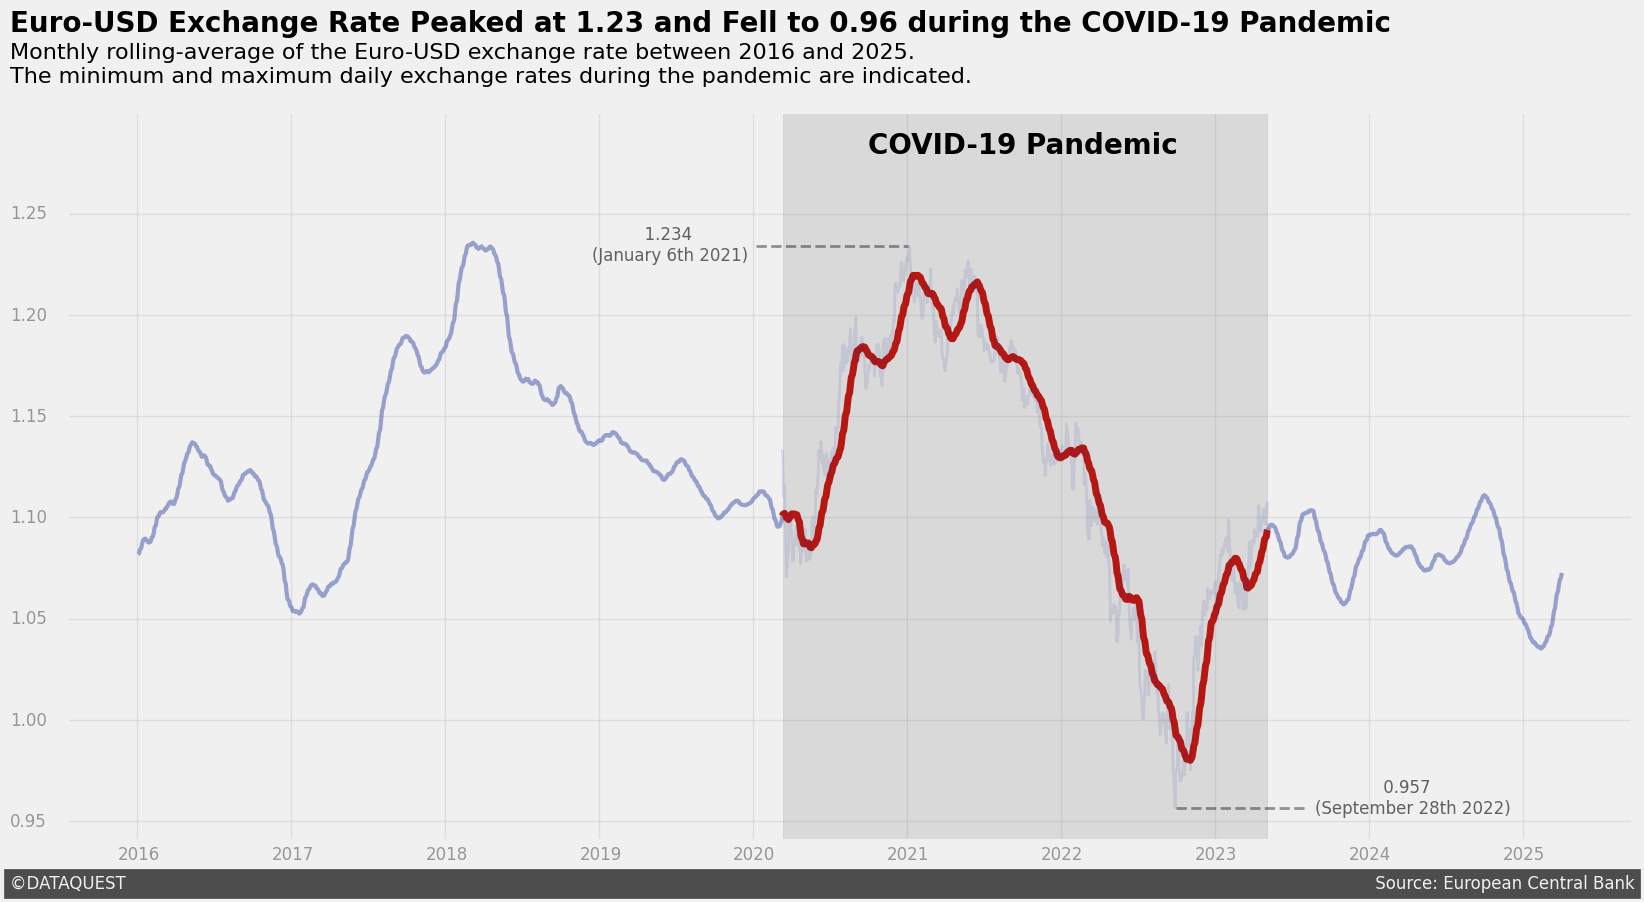

In [24]:
style.use("fivethirtyeight")

fig, ax = plt.subplots(figsize=(18, 9))

# plot 2016 to 2025 data
ax.plot(usd_data_2016_2025["Time"], usd_data_2016_2025["monthly_rolling_mean"], linewidth=3, color="#132797", alpha=0.4)

# set axis limits
ax.set_ylim(0.94, 1.3)

# highlight the WHO pandemic time period
ax.plot(usd_data_covid["Time"], usd_data_covid["monthly_rolling_mean"], linewidth=5, color="#b51812")

# overlay the daily exchange rate during the pandemic
ax.plot(usd_data_covid["Time"], usd_data_covid["US_dollar"], linewidth=2, color="#132797", alpha=0.1)

# enclose the COVID-19 pandemic time period
ax.axvspan("2020-03-11", "2023-05-05", alpha=0.2, color="grey")

# add COVID-19 pandemic label
ax.text(18535, 1.28, "COVID-19 Pandemic", fontsize=20, weight="bold")

# remove automatic axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# manually add x-axis labels
x = 16755
for year in ["2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]:
    ax.text(x, 0.9310, year, fontsize=12, color="grey", alpha=0.8)
    x += 365
    
# manually add y-axis labels
y = 0.9475
for rate in ["0.95", "1.00", "1.05", "1.10", "1.15", "1.20", "1.25"]:
    ax.text(16500, y, rate, fontsize=12, color="grey", alpha=0.8)
    y += 0.05
    
# soften gridlines
ax.grid(alpha=0.5)

# add label for minimum during pandemic
ax.axhline(0.9564, linewidth=2, color="black", alpha=0.4, linestyle="dashed", xmin=0.708, xmax=0.79)
ax.text(19595, 0.9540, " "*13 + "0.957 \n(September 28th 2022)", fontsize=12, color="black", alpha=0.6)

# add label for maximum during pandemic
ax.axhline(1.234, linewidth=2, color="black", alpha=0.4, linestyle="dashed", xmin=0.44, xmax=0.537)
ax.text(17880, 1.227, " "*10 + "1.234 \n(January 6th 2021)", fontsize=12, color="black", alpha=0.6)

# add title
ax.text(16500, 1.34, "Euro-USD Exchange Rate Peaked at 1.23 and Fell to 0.96 during the COVID-19 Pandemic", fontsize=20, weight="bold")

# add subtitle
ax.text(16500, 1.315, "Monthly rolling-average of the Euro-USD exchange rate between 2016 and 2025. \nThe minimum and maximum daily exchange rates during the pandemic are indicated.", fontsize=16)

# add signature
ax.text(16500, 0.917, "©DATAQUEST" + " "*238 + "Source: European Central Bank", fontsize=12, color="#f0f0f0", backgroundcolor="#4d4d4d")

plt.show()

It will be interesting to compare this to the exchange rate of the UK Pound Sterling.

---
# How did the COVID-19 Pandemic Influence the Euro-to-Pound Exchange Rate?

In [25]:
gbp_data_2016_2025 = gbp[gbp["Time"].between("2016-01-01", "2025-04-02")]

gbp_data_covid = gbp[gbp["Time"].between("2020-03-11", "2023-05-05")]

gbp_data_covid

,Time,UK_pound_sterling,monthly_rolling_mean
5486,2020-03-11,0.87690,0.849172
5487,2020-03-12,0.88623,0.850652
5488,2020-03-13,0.89070,0.852284
5489,2020-03-16,0.90918,0.854331
5490,2020-03-17,0.90823,0.856312
...,...,...,...
6291,2023-04-28,0.88050,0.880396
6292,2023-05-02,0.87868,0.880412
6293,2023-05-03,0.88265,0.880671
6294,2023-05-04,0.88015,0.880822


In [26]:
gbp_data_covid[gbp_data_covid["UK_pound_sterling"] == gbp_data_covid["UK_pound_sterling"].max()] # find maximum daily exchange rate during the covid period

,Time,UK_pound_sterling,monthly_rolling_mean
5492,2020-03-19,0.92985,0.861611


In [27]:
gbp_data_covid[gbp_data_covid["UK_pound_sterling"] == gbp_data_covid["UK_pound_sterling"].min()] # find minimum daily exchange rate during the covid period

,Time,UK_pound_sterling,monthly_rolling_mean
5996,2022-03-04,0.82388,0.836062


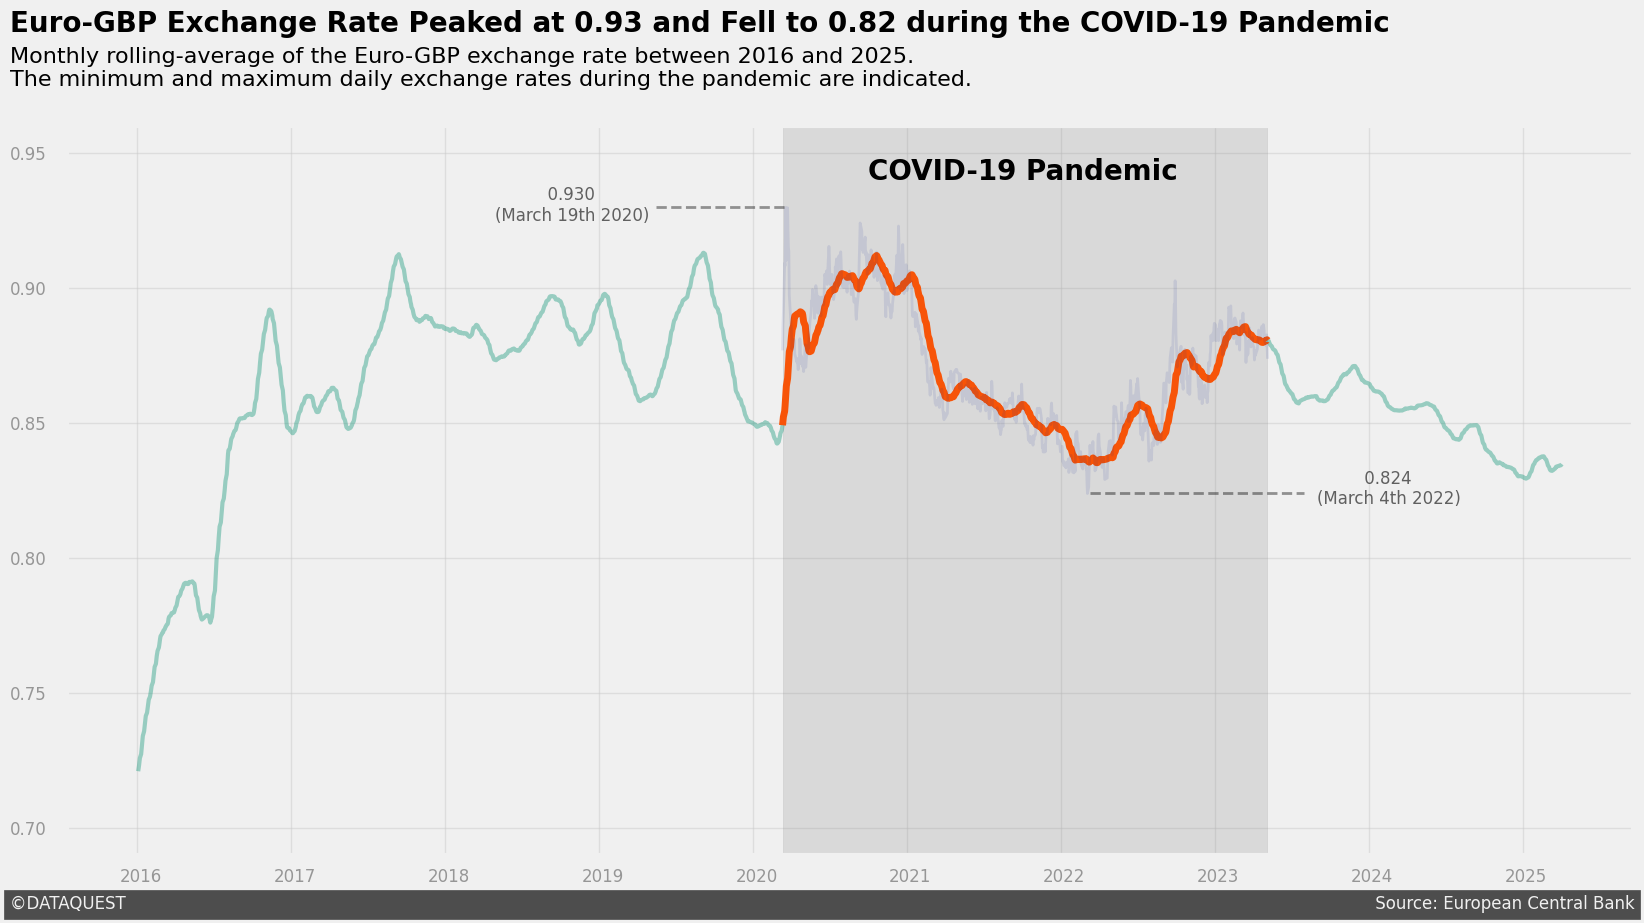

In [28]:
fig, ax = plt.subplots(figsize=(18, 9))

# plot 2016 to 2025 data
ax.plot(gbp_data_2016_2025["Time"], gbp_data_2016_2025["monthly_rolling_mean"], linewidth=3, color="#13977A", alpha=0.4)

# set axis limits
ax.set_ylim(0.69, 0.96)

# highlight the WHO pandemic time period
ax.plot(gbp_data_covid["Time"], gbp_data_covid["monthly_rolling_mean"], linewidth=5, color="#f75408")

# overlay the daily exchange rate during the pandemic
ax.plot(gbp_data_covid["Time"], gbp_data_covid["UK_pound_sterling"], linewidth=2, color="#132797", alpha=0.1)

# enclose the COVID-19 pandemic time period
ax.axvspan("2020-03-11", "2023-05-05", alpha=0.2, color="grey")

# add COVID-19 pandemic label
ax.text(18535, 0.94, "COVID-19 Pandemic", fontsize=20, weight="bold")

# remove automatic axis tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# manually add x-axis labels
x = 16760
for year in ["2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]:
    ax.text(x, 0.68, year, fontsize=12, color="grey", alpha=0.8)
    x += 365
    
# manually add y-axis labels
y = 0.6975
for rate in ["0.70", "0.75", "0.80", "0.85", "0.90", "0.95"]:
    ax.text(16500, y, rate, fontsize=12, color="grey", alpha=0.8)
    y += 0.05
    
# soften gridlines
ax.grid(alpha=0.5)

# add label for minimum during pandemic
ax.axhline(0.824, linewidth=2, color="black", alpha=0.4, linestyle="dashed", xmin=0.653, xmax=0.79)
ax.text(19600, 0.820, " "*9 + "0.824 \n(March 4th 2022)", fontsize=12, color="black", alpha=0.6)

# add label for maximum during pandemic
ax.axhline(0.93, linewidth=2, color="black", alpha=0.4, linestyle="dashed", xmin=0.376, xmax=0.460)
ax.text(17650, 0.925, " "*10 + "0.930 \n(March 19th 2020)", fontsize=12, color="black", alpha=0.6)

# add title
ax.text(16500, 0.995, "Euro-GBP Exchange Rate Peaked at 0.93 and Fell to 0.82 during the COVID-19 Pandemic", fontsize=20, weight="bold")

# add subtitle
ax.text(16500, 0.975, "Monthly rolling-average of the Euro-GBP exchange rate between 2016 and 2025. \nThe minimum and maximum daily exchange rates during the pandemic are indicated.", fontsize=16)

# add signature
ax.text(16500, 0.67, "©DATAQUEST" + " "*238 + "Source: European Central Bank", fontsize=12, color="#f0f0f0", backgroundcolor="#4d4d4d")

plt.show()

## Comparing Trends

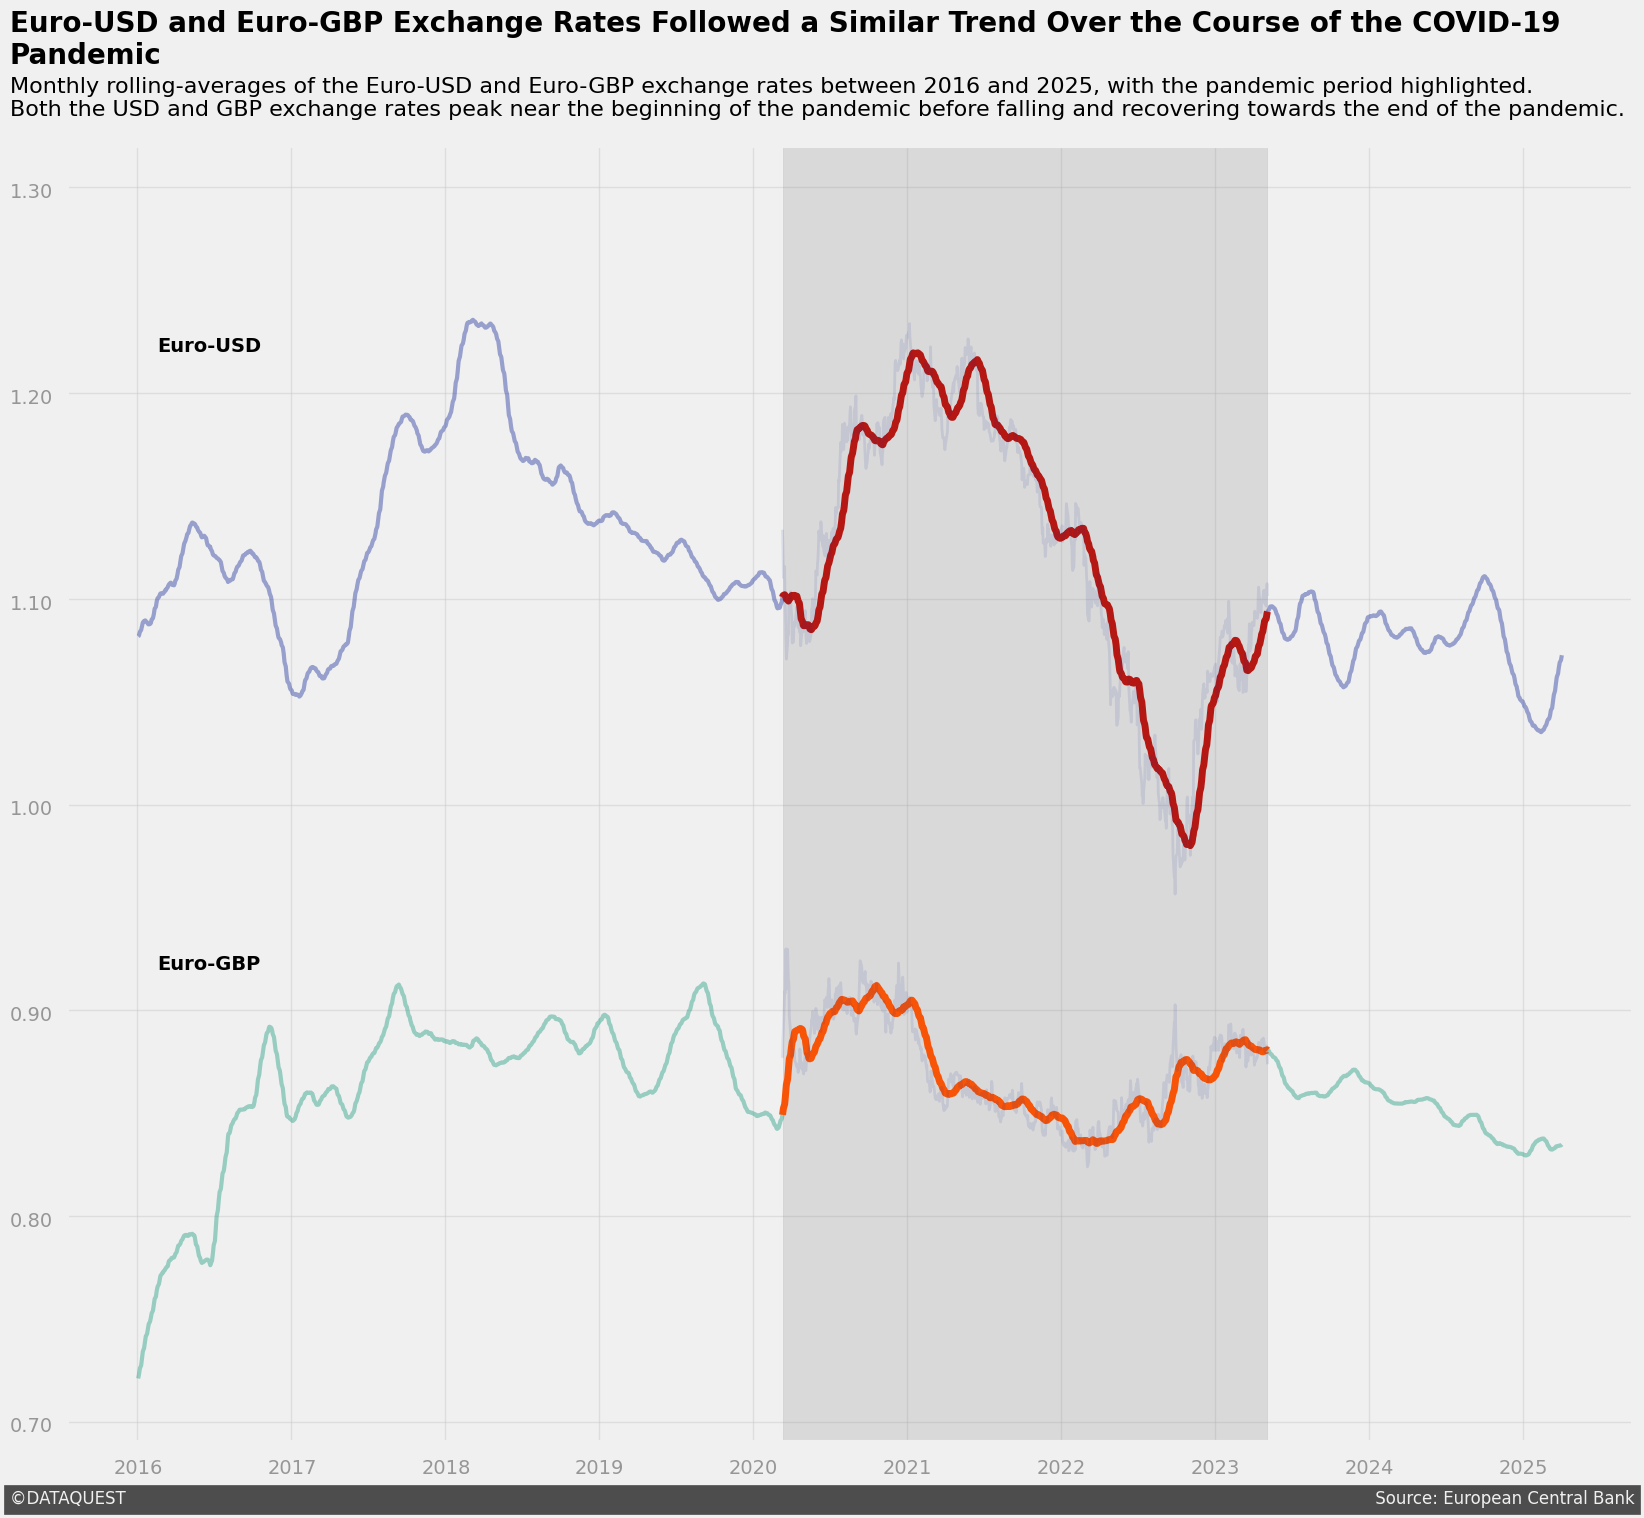

In [29]:
fig, ax = plt.subplots(figsize=(18, 16))

"""Plot Eur-USD Data"""

ax.plot(usd_data_2016_2025["Time"], usd_data_2016_2025["monthly_rolling_mean"], linewidth=3, color="#132797", alpha=0.4)

ax.plot(usd_data_covid["Time"], usd_data_covid["monthly_rolling_mean"], linewidth=5, color="#b51812")

ax.plot(usd_data_covid["Time"], usd_data_covid["US_dollar"], linewidth=2, color="#132797", alpha=0.1)

"""Plot Eur-GBP Data"""

ax.plot(gbp_data_2016_2025["Time"], gbp_data_2016_2025["monthly_rolling_mean"], linewidth=3, color="#13977A", alpha=0.4)

ax.plot(gbp_data_covid["Time"], gbp_data_covid["monthly_rolling_mean"], linewidth=5, color="#f75408")

ax.plot(gbp_data_covid["Time"], gbp_data_covid["UK_pound_sterling"], linewidth=2, color="#132797", alpha=0.1)

# set y axis limit

ax.set_ylim(0.69, 1.32)

# highlight the WHO pandemic time period

ax.axvspan("2020-03-11", "2023-05-05", alpha=0.2, color="grey")

# soften gridlines

ax.grid(alpha=0.5)

# remove automatic axis tick labels

ax.set_xticklabels([])

ax.set_yticklabels([])

# manually add axis labels

x = 16745
for year in ["2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]:
    ax.text(x, 0.675, year, fontsize=14, color="grey", alpha=0.8)
    x += 365
    
y = 0.6950
for rate in ["0.70", "0.80", "0.90", "1.00", "1.10", "1.20", "1.30"]:
    ax.text(16500, y, rate, fontsize=14, color="grey", alpha=0.8)
    y += 0.1
    
# add labels for each time series
    
ax.text(16850, 1.22, "Euro-USD", fontsize=14, weight="bold")
ax.text(16850, 0.92, "Euro-GBP", fontsize=14, weight="bold")

ax.text(16500, 1.36, "Euro-USD and Euro-GBP Exchange Rates Followed a Similar Trend Over the Course of the COVID-19\nPandemic", fontsize=20, weight="bold")
ax.text(16500, 1.335, "Monthly rolling-averages of the Euro-USD and Euro-GBP exchange rates between 2016 and 2025, with the pandemic period highlighted. \nBoth the USD and GBP exchange rates peak near the beginning of the pandemic before falling and recovering towards the end of the pandemic.", fontsize=16)

# add signature
    
ax.text(16500, 0.66, "©DATAQUEST" + " "*238 + "Source: European Central Bank", fontsize=12, color="#f0f0f0", backgroundcolor="#4d4d4d")

plt.show()

## Remarks

Obviously, there are many other factors at play beyond just the pandemic which will all have an influence on the exchange rates over this period. It is very difficult to pinpoint the exact causes for the variation due to the multi-variate nature of the dependent variable. We can however, describe the key trends for both USD and GBP over the period and how it compares to pre- and post-pandemic rates.

>* Both USD and GBP follow a similar trend - the currency significantly weakens at the beginning of the pandemic (since the exchange rates tend towards a local maximum in the first year of the pandemic period). 
>
>* Moving towards the middle and end of the pandemic, both rates show a sharp drop, tending towards a local minimum (the USD/GBP becomes stronger relative to the Euro). 
>
>* At the end of the pandemic period, we see both Euro-USD and Euro-GBP rates sharply rise again (USD/GBP weakens relative to the Euro). 


## Conclusion

This report has created two explanatory data visualizations to illustrate the Euro-USD and Euro-GBP exchange rates before, during and after the COVID-19 Pandemic. These graphics were created with Gestalt principles as well as pre-attentive attributes in mind, creating clear, unambiguous visualizations that are publication-ready. 

The audience would not need signigicant prior knowledge to read the graph as simple line plots are used to display the time series data.